# Importa as bibliotecas

In [12]:
%matplotlib widget

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Abre a imagens no espaco de cor correta

In [13]:
img = cv.imread('Kolonie18630131-p04.png')
assert img is not None, "file could not be read, check with os.path.exists()"
rows, cols, ch = img.shape
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

libpng warning: iCCP: CRC error


# Cria um widget para selecionar os quatro cantos da imagem antes de aplicar a transformação de perspectiva.

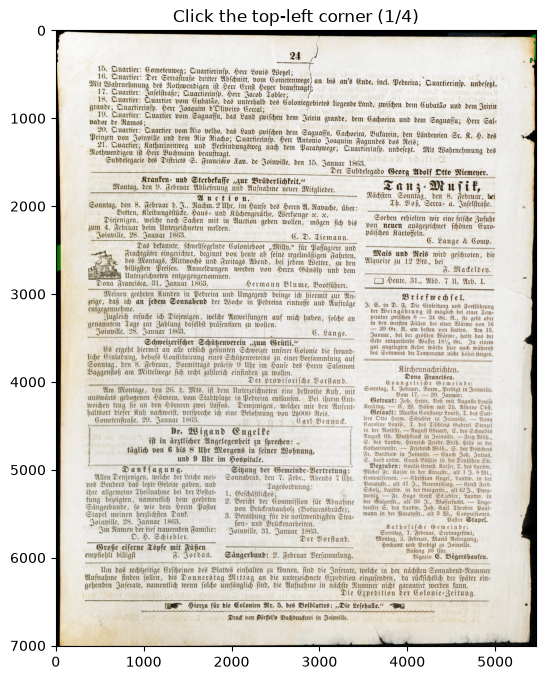

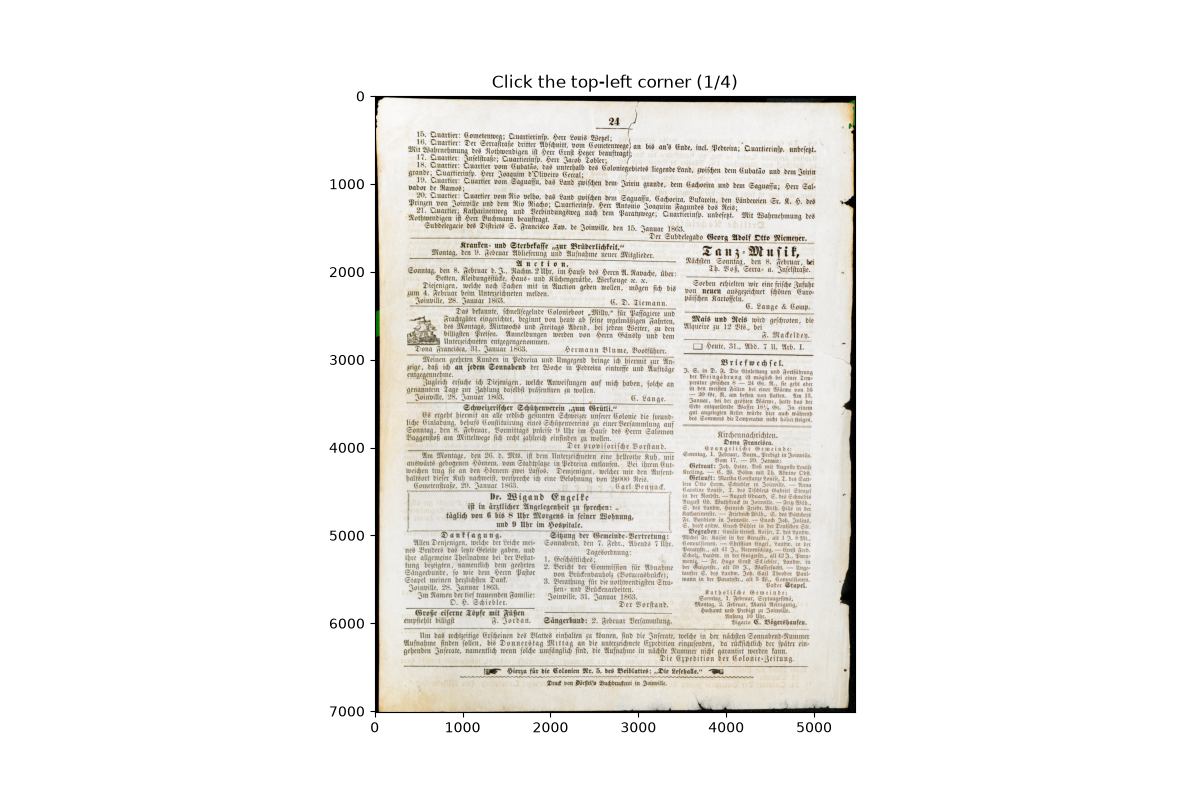

In [14]:
point_names = ["top-left", "top-right", "bottom-right", "bottom-left"]
selected_points = []
point_labels = []

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img_rgb)
ax.set_title("Click the top-left corner (1/4)")
points_artist, = ax.plot([], [], "ro", markersize=7)
selection_status = widgets.HTML("Click the top-left corner, then continue clockwise.")
reset_button = widgets.Button(description="Reset points", icon="undo")


def on_image_click(event):
    if event.inaxes is not ax or event.xdata is None or event.ydata is None:
        return
    if len(selected_points) >= 4:
        return

    selected_points.append((event.xdata, event.ydata))
    point_labels.append(
        ax.annotate(str(len(selected_points)), (event.xdata, event.ydata),
                    color="yellow", fontsize=12, fontweight="bold")
    )
    points_artist.set_data(
        [point[0] for point in selected_points],
        [point[1] for point in selected_points]
    )

    if len(selected_points) == 4:
        ax.set_title("Four corners selected. Run the transform cell below.")
        selection_status.value = "All four points selected."
    else:
        next_name = point_names[len(selected_points)]
        ax.set_title(f"Click the {next_name} corner ({len(selected_points) + 1}/4)")
        selection_status.value = f"Next point: {next_name}."
    fig.canvas.draw_idle()


def reset_points(_event):
    selected_points.clear()
    points_artist.set_data([], [])
    for label in point_labels:
        label.remove()
    point_labels.clear()
    ax.set_title("Click the top-left corner (1/4)")
    selection_status.value = "Click the top-left corner, then continue clockwise."
    fig.canvas.draw_idle()


fig.canvas.mpl_connect("button_press_event", on_image_click)
reset_button.on_click(reset_points)
display(widgets.HBox([reset_button, selection_status]), fig)

In [19]:
initial_xlim = ax.get_xlim()
initial_ylim = ax.get_ylim()


def zoom_image(event):
    if event.inaxes is not ax or event.xdata is None or event.ydata is None:
        return

    scale = 1 / 1.2 if event.button == "up" else 1.2
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    ax.set_xlim(
        event.xdata + (x_min - event.xdata) * scale,
        event.xdata + (x_max - event.xdata) * scale
    )
    ax.set_ylim(
        event.ydata + (y_min - event.ydata) * scale,
        event.ydata + (y_max - event.ydata) * scale
    )
    fig.canvas.draw_idle()


def reset_zoom(_event):
    ax.set_xlim(initial_xlim)
    ax.set_ylim(initial_ylim)
    fig.canvas.draw_idle()


fig.canvas.mpl_connect("scroll_event", zoom_image)
reset_zoom_button = widgets.Button(description="Reset zoom", icon="search")
reset_zoom_button.on_click(reset_zoom)
display(reset_zoom_button)

Button(description='Reset zoom', icon='search', style=ButtonStyle())

In [18]:
print("Debugging perspective transformation")
print("Selected points:", selected_points)

Debugging perspective transformation
Selected points: [(np.float64(413.0064935064938), np.float64(1626.8214285714284)), (np.float64(5010.474025974028), np.float64(1672.340909090909)), (np.float64(4942.1948051948075), np.float64(6508.785714285714)), (np.float64(333.34740259740283), np.float64(6520.165584415585))]


# Aplica as transformacoes para deixar a imagem reta

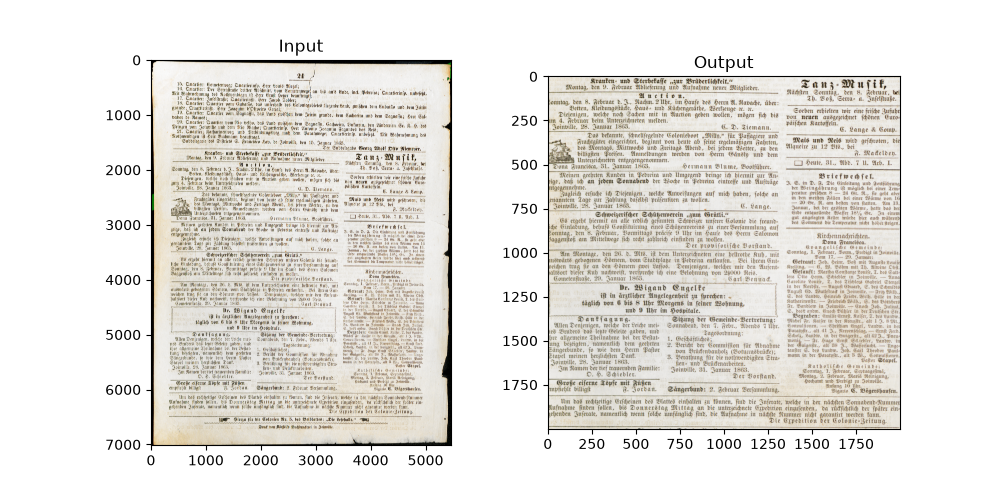

In [17]:
if len(selected_points) != 4:
    raise ValueError("Select all four corners in the image before transforming.")

pts1 = np.float32(selected_points)
pts2 = np.float32([[0, 0], [2000, 0], [2000, 2000], [0, 2000]])

M = cv.getPerspectiveTransform(pts1, pts2)
dst = cv.warpPerspective(img, M, (2000, 2000))

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(img_rgb)
plt.title("Input")
plt.subplot(122)
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))
plt.title("Output")
plt.show()